将单个被试INT脑区映射到网络

In [2]:
import pandas as pd

# ==========================================
# 1. 读取映射表和数据
# ==========================================
region_mapping_path = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv'
region_mapping_df = pd.read_csv(region_mapping_path)
# 建立脑区到网络的映射字典
region_to_network = region_mapping_df.set_index('regions')['Yeo_7network'].to_dict()

subtype_data_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step3_Structure/HC_GrayVol246.csv'
data_df = pd.read_csv(subtype_data_path)
print(f"原始数据形状: {data_df.shape}")

# ==========================================
# 2. 关键修改：提取前 7 列基础信息
# ==========================================
# 提取前 7 列 (subID, TIV, age, sex, site, sitenum, MDD)
info_df = data_df.iloc[:, :7]

# 提取脑区数据 (从第 8 列 A8m_R 开始)
data_of_interest = data_df.iloc[:, 7:]

# ==========================================
# 3. 按网络计算平均值
# ==========================================
# 初始化网络数据容器
unique_networks = set(region_to_network.values())
network_data = {network: [] for network in unique_networks}

# 将脑区列分配到对应的网络中
for column in data_of_interest.columns:
    if column in region_to_network:
        network = region_to_network[column]
        network_data[network].append(data_of_interest[column])

# 计算每个网络的平均值
network_averages = {}
for network, data_list in network_data.items():
    if data_list:
        # 将列表中的 Series 合并后计算横向平均值
        network_df = pd.concat(data_list, axis=1)
        network_averages[str(network)] = network_df.mean(axis=1)

# 转为 DataFrame
result_net_df = pd.DataFrame(network_averages)

# ==========================================
# 4. 列名映射 (0-7 -> 对应名称)
# ==========================================
column_mapping = {
    '0': 'subcortical',
    '1': 'Visual',
    '2': 'Somatomotor',
    '3': 'Dorsal Attention',
    '4': 'Ventral Attention',
    '5': 'Limbic',
    '6': 'Frontoparietal',
    '7': 'Default'
}
# 重命名网络列
result_net_df.rename(columns=column_mapping, inplace=True)

# 按照指定的 8 网络顺序排列（可选，确保列顺序固定）
network_order = [
    'subcortical', 'Visual', 'Somatomotor', 'Dorsal Attention',
    'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default'
]
result_net_df = result_net_df.reindex(columns=network_order)

# ==========================================
# 5. 合并前 7 列与网络结果并保存
# ==========================================
final_df = pd.concat([info_df, result_net_df], axis=1)

result_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step3_Structure/HC_GMV_7net.csv'
final_df.to_csv(result_path, index=False)

print(f"计算完成！")
print(f"前 7 列已包含: {list(info_df.columns)}")
print(f"网络列已包含: {list(result_net_df.columns)}")
print(f"最终结果已保存到: {result_path}")

原始数据形状: (225, 259)
计算完成！
前 7 列已包含: ['subID', 'TIV', 'age', 'sex', 'site', 'sitenum', 'MDD']
网络列已包含: ['subcortical', 'Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']
最终结果已保存到: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step3_Structure/HC_GMV_7net.csv


将一组被试INT脑区映射到网络


In [3]:
import pandas as pd

# ================== 1. 读取 Yeo 7-network 映射表 ==================
region_mapping_path = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv'
region_mapping_df = pd.read_csv(region_mapping_path)

# 建立 脑区名称 → Yeo_7network 的映射字典
region_to_network = region_mapping_df.set_index('regions')['Yeo_7network'].to_dict()

print(f"成功加载映射表，共 {len(region_to_network)} 个脑区")

# ================== 2. 读取数据 ==================
# 这里换成了你上传的带有 mean_fd 的数据路径
data_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_verify/HC_DZ_INT_agesex_FD.csv'
data_df = pd.read_csv(data_path)

print(f"原始数据形状: {data_df.shape}")
print(f"被试数量: {len(data_df)}")

# ================== 3. 提取协变量与脑区数据 ==================
# 明确指定需要保留在最终结果中的人口学/协变量列
covariates_cols = ['subID', 'mean_fd', 'age', 'sex']
covariates_df = data_df[covariates_cols].copy()

# 自动提取所有脑区列（即排除刚刚指定的协变量列）
brain_regions = [col for col in data_df.columns if col not in covariates_cols]
data_of_interest = data_df[brain_regions]

# ================== 4. 按 8 个网络 (Yeo 7 + 0皮层下) 分组 ==================
# 获取所有可能的网络名称（0~7，共8个）
networks = sorted(set(region_to_network.values()))
network_data = {net: [] for net in networks}

print("开始将脑区映射到 Yeo 7 (含皮层下共8个) 网络...")

for col in data_of_interest.columns:
    if col in region_to_network:
        network = region_to_network[col]
        network_data[network].append(data_of_interest[col])
    else:
        print(f"警告：列 {col} 不在映射表中，已跳过")

# ================== 5. 计算每个网络的平均值 ==================
network_averages = {}

for network, series_list in network_data.items():
    if series_list:
        # 把同一个网络的所有脑区列合并成一个 DataFrame
        network_df = pd.concat(series_list, axis=1)
        # 计算每个被试在该网络所有脑区的平均值
        network_mean = network_df.mean(axis=1)
        network_averages[network] = network_mean
    else:
        print(f"警告：网络 {network} 没有任何脑区")

# ================== 6. 构建结果 DataFrame 并合并数据 ==================
# 将计算好的网络均值转为 DataFrame
computed_network_df = pd.DataFrame(network_averages)

# 8 个网络的名称映射
column_mapping = {
    0: 'Subcortical',
    1: 'Visual',
    2: 'Somatomotor',
    3: 'Dorsal_Attention',
    4: 'Ventral_Attention',
    5: 'Limbic',
    6: 'Frontoparietal',
    7: 'Default'
}

computed_network_df.rename(columns=column_mapping, inplace=True)

# 将原有的 subID, mean_fd, age, sex 拼接在网络结果的左侧
result_df = pd.concat([covariates_df, computed_network_df], axis=1)

# ================== 7. 保存结果 ==================
# 建议修改下输出文件名以防止覆盖，这里加了 _8net 后缀
result_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_verify/HC_DZ_INT_8net.csv'
result_df.to_csv(result_path, index=False)

print(f"\n统计结果 CSV 已成功保存至: {result_path}")
print("输出数据预览:")
print(result_df.head())

成功加载映射表，共 246 个脑区
原始数据形状: (38, 250)
被试数量: 38
开始将脑区映射到 Yeo 7 (含皮层下共8个) 网络...

统计结果 CSV 已成功保存至: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_verify/HC_DZ_INT_8net.csv
输出数据预览:
             subID   mean_fd  age  sex  Subcortical    Visual  Somatomotor  \
0  sub-07000008V01  0.149986   29    2     3.050772  3.704076     3.494544   
1  sub-07000009V01  0.077896   25    2     3.021827  3.589714     4.060699   
2  sub-07000026V01  0.049480   47    2     3.040876  3.365968     3.894521   
3  sub-07000035V01  0.086814   23    2     3.108776  3.430164     3.679676   
4  sub-07000041V01  0.080487   29    1     3.429590  3.864323     4.075409   

   Dorsal_Attention  Ventral_Attention    Limbic  Frontoparietal   Default  
0          3.540008           3.380294  3.490907        3.711589  3.741382  
1          4.025548           3.722861  3.290500        3.839207  3.810954  
2          3.579021           3.529721  3.342018        3.991736  3.683489  
3          3.539369           3.734961  3.

/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_8115/1331747678.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Value',


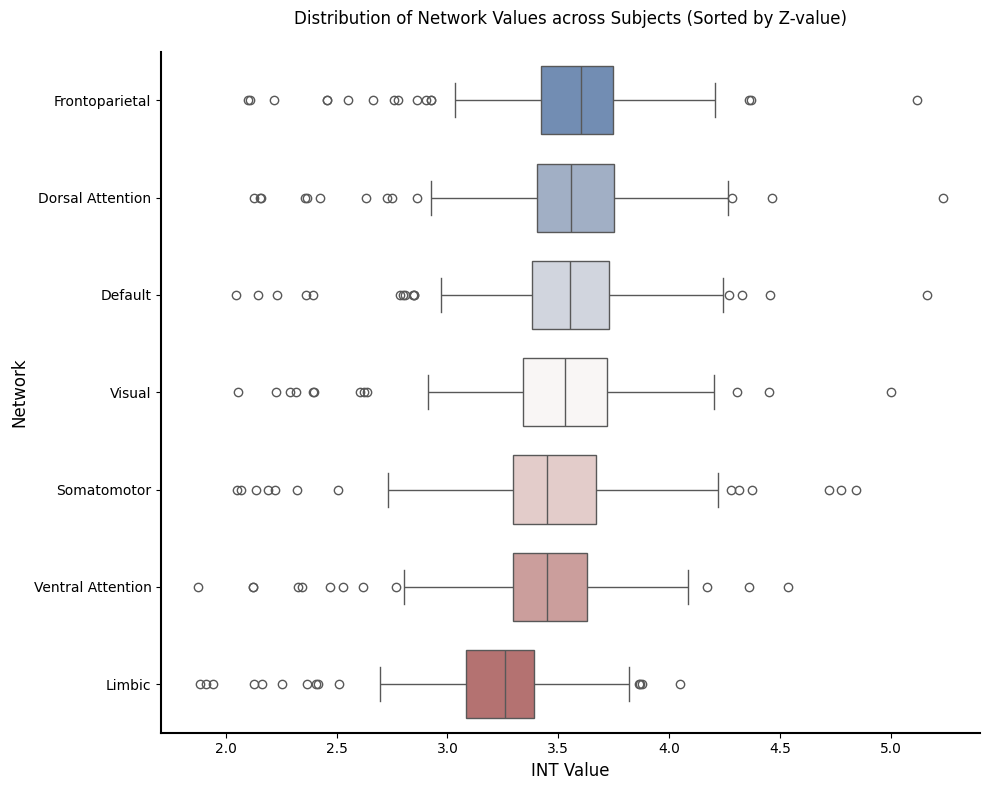

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
dpath = '/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/volume/INTvalue_HCgroup_net7.csv'
# 从 CSV 文件中读取数据
df = pd.read_csv(dpath)

# # 将数据转换为长格式
df_long = df.melt(id_vars=['subID', '0'],
                 value_vars=['Visual', 'Somatomotor', 'Dorsal Attention',
                            'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default'],
                 var_name='Network',
                 value_name='Value')

# # 将数据转换为长格式
# df_long = df.melt(id_vars=['subID'],
#                   value_vars=['DorsAttn', 'Cont', 'SalVentAttn', 'SomMot', 'Default', 'Limbic', 'Vis'],
#                   var_name='Network',
#                   value_name='Value')


# 计算每个网络的z轴值（这里假设是均值，可根据实际需求修改）
network_z_values = df_long.groupby('Network')['Value'].mean().sort_values(ascending=False)

# 获取排序后的网络顺序
network_order = network_z_values.index.tolist()

plt.figure(figsize=(10, 8))

# 绘制横向箱体图，使用排序后的网络顺序
ax = sns.boxplot(x='Value',
            y='Network',
            data=df_long,
            order=network_order,
            orient='h',
            palette='vlag',
            width=0.7)

# 设置背景颜色为透明
ax.set_facecolor('none')

# 关闭网格线显示
ax.grid(False)

# 确保坐标轴可见
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置坐标轴颜色和线宽
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# 添加标题和标签
plt.title('Distribution of Network Values across Subjects (Sorted by Z-value)', pad=20)
plt.xlabel('INT Value', fontsize=12)
plt.ylabel('Network', fontsize=12)
plt.savefig('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/volume/7net.png', dpi=300)
# 调整布局
plt.tight_layout()
plt.show()


/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_8115/1643807640.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Value',


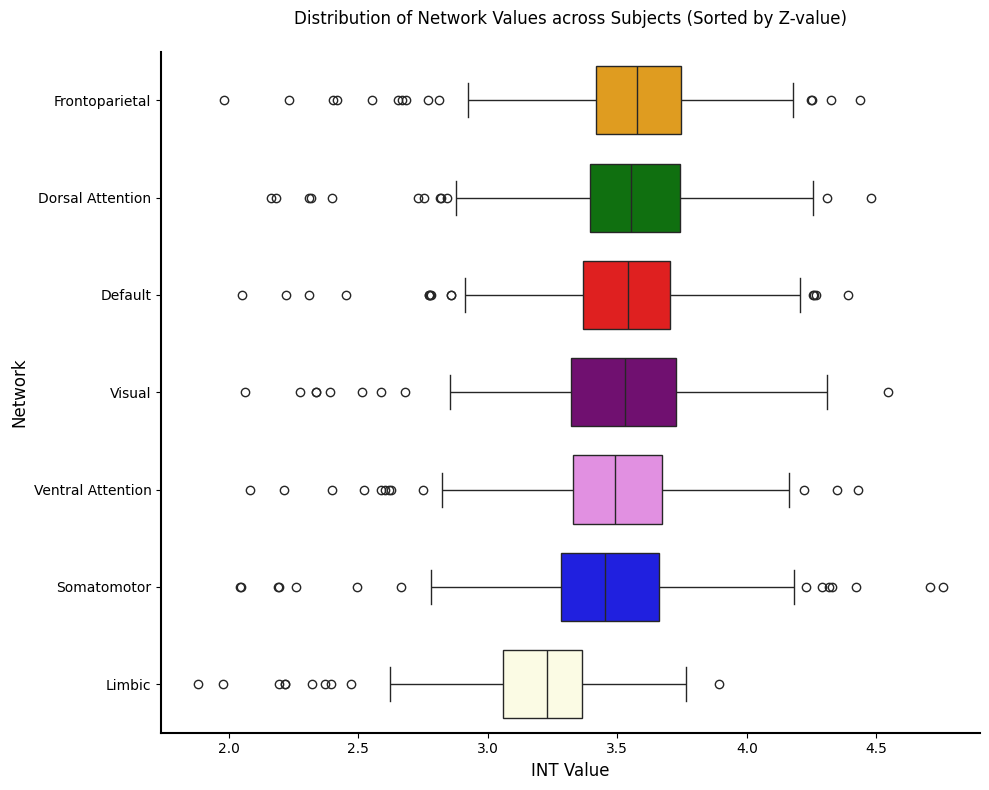

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 从 CSV 文件中读取数据
df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/Results/INTvalue_HCgroup_net7.csv')

# 将数据转换为长格式
df_long = df.melt(id_vars=['subID', '0'],
                 value_vars=['Visual', 'Somatomotor', 'Dorsal Attention',
                            'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default'],
                 var_name='Network',
                 value_name='Value')

# 计算每个网络的z轴值（这里假设是均值，可根据实际需求修改）
network_z_values = df_long.groupby('Network')['Value'].mean().sort_values(ascending=False)

# 获取排序后的网络顺序
network_order = network_z_values.index.tolist()

# 创建自定义颜色映射
custom_palette = {
    'Visual': 'purple',
    'Somatomotor': 'blue',
    'Dorsal Attention': 'green',
    'Ventral Attention': 'violet',
    'Limbic': 'lightyellow',
    'Frontoparietal': 'orange',
    'Default': 'red'
}

plt.figure(figsize=(10, 8))

# 绘制横向箱体图，使用排序后的网络顺序和自定义颜色
ax = sns.boxplot(x='Value',
            y='Network',
            data=df_long,
            order=network_order,
            orient='h',
            palette=custom_palette,
            width=0.7)

# 设置背景颜色为透明
ax.set_facecolor('none')

# 关闭网格线显示
ax.grid(False)

# 确保坐标轴可见
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置坐标轴颜色和线宽
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# 添加标题和标签
plt.title('Distribution of Network Values across Subjects (Sorted by Z-value)', pad=20)
plt.xlabel('INT Value', fontsize=12)
plt.ylabel('Network', fontsize=12)
plt.savefig('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/Results/7net.png', dpi=300)

# 调整布局
plt.tight_layout()
plt.show()


提取数据

In [6]:
import glob
import os
from shutil import copy
path = '/Volumes/QCII/Data135_processed/xcpd_out_mdd/xcp_d/sub-MDD*/func/*_task-rest_acq-ap_run-1_space-fsLR_atlas-4S456Parcels_den-91k_measure-pearsoncorrelation_conmat.pconn.nii'

data = glob.glob(path)

for i in data:

    subID = i.split('/')[-3]
    finame = i.split('/')[-1]

    newpth = '/Volumes/QC/Data/Schaefer400_FC/MDD_BP135/'+finame

    copy(i, newpth)



合并数据-两表相同

In [1]:
import numpy as np
import pandas as pd
file_1 ='/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/INTvalue_MDD.csv'
file_2 ='/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/clinicalInformation/MDD_age_sex.csv'

#Read the CSV files into DataFrames
df1 = pd.read_csv(file_1)
df2 = pd.read_csv(file_2)

df_new = pd.merge(df2, df1, on='subID', how='inner')
df_new.to_csv('/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/INT_MDD.csv', index=False,encoding='utf-8-sig')


BLR模型结果检查-针对EXPV文件

In [5]:
import glob

import pandas as pd

path = "/Volumes/QC/INT/INT_BN246_HC_MDD/INT_NM/Results/INT246_BLR_20251111/NMResults/INT_246/*/EXPV_estimate.txt"

data = glob.glob(path)
region_values = []
for i in data:
    regionname = i.split('/')[-2]


    with open(i, 'r') as file:
        value = file.read().strip()
        # 将 regionname 和值作为一个列表添加到 region_values 中
    region_values.append([regionname, value])

df = pd.DataFrame(region_values, columns=['RegionName', 'EXPV'])
csv_path = "./expv.csv"
df.to_csv(csv_path, index=False)

GPR模型结果检查

In [7]:
import pandas as pd
import numpy as np

def pkltocsv(Resultpath,labelpath,columnsname,opath,mark):
    Rho_AllHCestimate = pd.read_pickle(Resultpath+'Rho_'+mark+'.pkl')
    print(Rho_AllHCestimate.shape)
    pRho_AllHCestimate = pd.read_pickle(Resultpath+'pRho_'+mark+'.pkl')
    print(pRho_AllHCestimate.shape)
    SMSE_AllHCestimate = pd.read_pickle(Resultpath+'SMSE_'+mark+'.pkl')
    print(SMSE_AllHCestimate.shape)
    RMSE_AllHCestimate = pd.read_pickle(Resultpath+'RMSE_'+mark+'.pkl')
    print(RMSE_AllHCestimate.shape)
    yhat_AllHCestimate = pd.read_pickle(Resultpath+'yhat_'+mark+'.pkl')
    print(yhat_AllHCestimate.shape)
    EXPV_AllHCestimate = pd.read_pickle(Resultpath + 'EXPV_' + mark + '.pkl')
    print(EXPV_AllHCestimate.shape)
    MSLL_AllHCestimate = pd.read_pickle(Resultpath + 'MSLL_' + mark + '.pkl')

    label = pd.read_csv(labelpath)
    brainRegion = label.columns.tolist()
    a = brainRegion[4:]
    regions = pd.DataFrame(a)


    df_sum = pd.concat([regions, Rho_AllHCestimate, pRho_AllHCestimate, RMSE_AllHCestimate, SMSE_AllHCestimate, EXPV_AllHCestimate,MSLL_AllHCestimate],
                       axis=1)  # 将两列拼接在一起，axis=1 表示按列拼接
    df_sum.columns = columnsname
    df_sum.to_csv(opath)
columnsname = ['Regions','Rho', 'pRho', 'RMSE', 'SMSE', 'EXPV','MSLL']

Resultpath = '/Volumes/QC/INT/INT_BN246_HC_MDD/INT_NM/Results/INT246_GPR_20251112/NMResults/'
labelpath = '/Volumes/QC/INT/INT_BN246_HC_MDD/INT_NM/Feature/HC_Train_harmonized.csv'
opath = '/Volumes/QC/INT/INT_BN246_HC_MDD/INT_NM/Results/INT246_GPR_20251112/NMResults/GPR_GrayVol246_HC_Discover_ResSum.csv'
mark = 'Test'
pkltocsv(Resultpath,labelpath,columnsname,opath,mark)
#
# Resultpath = '/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_10K_HCMDD_1022/NMResults/'
# mddlabel = '/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_10K_HCMDD_1022/NMResults/allMDD_GrayVol246_combat_final.csv'
# opath = '/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_10K_HCMDD_1022/StaResults/GPR_GrayVol246_MDD_ResSum.csv'
# mark = 'AllMDD'
# pkltocsv(Resultpath,mddlabel,columnsname,opath,mark)

(246, 1)
(246, 1)
(246, 1)
(246, 1)
(1088, 246)
(246, 1)


GPR模型提前 z值

In [ ]:
import pandas as pd

Z_AllHCestimate = pd.read_pickle('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_5K_HCMDD_1022/NMResults/Z_AllHCestimate.pkl')
#Z_AllHCestimate = pd.read_pickle('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_5K_HCMDD_1022/NMResults/Z_AllMDD.pkl')
label = pd.read_csv('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_5K_HCMDD_1022/NMResults/allHC_GrayVol246_combat_final.csv')

brainRegion = label.columns.tolist()
del brainRegion[0:7]


Z_AllHCestimate.columns = brainRegion

subIDs = label['subID']

zvalue = pd.concat([subIDs, Z_AllHCestimate], axis=1)

zvalue.to_csv('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_5K_HCMDD_1022/StaResults/GrayVol246_Z_AllHCestimate.csv')

In [6]:
import nibabel as nib

da = nib.load("/Volumes/QC/Data/INT/brianproject/HC/sub-01000018V01_task-rest_acq-ap_run-1_space-fsLR_den-91k_bold_smooth.dtseries.nii").get_fdata()
print(da.shape)

(240, 91282)


8网络 GMV 预测 8网络 INT Ridge

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# 1. 读取数据
file_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype2_INT_GMV_7net.csv'
df = pd.read_csv(file_path)

# 2. 定义 8 个网络名称以及对应的灰质体积（GMV）列名
networks = [
    'subcortical', 'Visual', 'Somatomotor', 'Dorsal_Attention',
    'Ventral_Attention', 'Limbic', 'Frontoparietal', 'Default'
]
gmv_cols = [col + '_GMV' for col in networks]


# ==================== 方式一：多对一预测 ====================
# 使用全部 8 个网络的 GMV 作为特征
X_all = df[gmv_cols]

results_all = []
for net in networks:
    y = df[net]
    # 岭回归（使用默认参数 alpha=1.0），10折交叉验证
    scores = cross_val_score(Ridge(), X_all, y, cv=10, scoring='r2')
    results_all.append({
        'Network': net,
        'R2': scores.mean()
    })

# 转换为 DataFrame 并计算 8 个网络的均值 R2
res_df_all = pd.DataFrame(results_all)
mean_r2_all = res_df_all['R2'].mean()

# 将均值结果添加至最后一行
mean_row_all = pd.DataFrame([{'Network': 'Mean', 'R2': mean_r2_all}])
res_df_all = pd.concat([res_df_all, mean_row_all], ignore_index=True)
print(res_df_all)
# 保存到 CSV
#res_df_all.to_csv('network_predict_r2_results.csv', index=False)

             Network        R2
0        subcortical -0.019946
1             Visual -0.033187
2        Somatomotor -0.071017
3   Dorsal_Attention -0.175248
4  Ventral_Attention -0.069497
5             Limbic -0.062873
6     Frontoparietal -0.204886
7            Default -0.235366
8               Mean -0.109002


8网络 GMV 预测 8网络 INT Lasso

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score

# 1. 读取数据
file_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype1_INT_GMV_7net.csv'
df = pd.read_csv(file_path)

# 2. 定义 8 个网络名称以及对应的灰质体积（GMV）列名
networks = [
    'subcortical', 'Visual', 'Somatomotor', 'Dorsal_Attention',
    'Ventral_Attention', 'Limbic', 'Frontoparietal', 'Default'
]
gmv_cols = [col + '_GMV' for col in networks]


# ==================== 方式一：多对一预测 ====================
# 使用全部 8 个网络的 GMV 作为特征
X_all = df[gmv_cols]

results_all = []
for net in networks:
    y = df[net]
    # 将模型改为 Lasso 回归（可根据需要调整 alpha 参数，如 Lasso(alpha=0.01)）
    scores = cross_val_score(Lasso(alpha=1.0), X_all, y, cv=10, scoring='r2')
    results_all.append({
        'Network': net,
        'R2': scores.mean()
    })

# 转换为 DataFrame 并计算 8 个网络的均值 R2
res_df_all = pd.DataFrame(results_all)
mean_r2_all = res_df_all['R2'].mean()

# 将均值结果添加至最后一行
mean_row_all = pd.DataFrame([{'Network': 'Mean', 'R2': mean_r2_all}])
res_df_all = pd.concat([res_df_all, mean_row_all], ignore_index=True)

# 打印输出结果
print(res_df_all)

# 保存到 CSV
#res_df_all.to_csv('network_predict_lasso_r2_results.csv', index=False)

             Network        R2
0        subcortical -0.105211
1             Visual -0.124171
2        Somatomotor -0.115537
3   Dorsal_Attention -0.076933
4  Ventral_Attention -0.017585
5             Limbic -0.069857
6     Frontoparietal -0.123405
7            Default -0.040277
8               Mean -0.084122


Neurosynth-Step_1 :计算得到 z-map

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

def run_step1_analysis(hc_file, subtype_file, output_file):
    print("====== 正在加载数据... ======")
    # 1. 读取 CSV 文件
    hc_df = pd.read_csv(hc_file)
    sub1_df = pd.read_csv(subtype_file)

    # 2. 标记分组变量 (健康对照组 HC = 0, 患者亚型 Subtype 1 = 1)
    hc_df['group'] = 0
    sub1_df['group'] = 1

    # 合并两个数据集
    combined_df = pd.concat([hc_df, sub1_df], ignore_index=True)

    # 3. 自动识别脑区列（排除 ID、年龄、性别和分组列）
    exclude_cols = ['subID', 'age', 'sex', 'group']
    roi_cols = [col for col in hc_df.columns if col not in exclude_cols]
    n_rois = len(roi_cols)
    print(f"成功加载数据！总样本量: {len(combined_df)} (HC: {len(hc_df)}, Subtype 1: {len(sub1_df)})")
    print(f"识别出脑区数量: {n_rois}")

    # 4. 构建协变量矩阵 X (包含截距项、组别、年龄、性别)
    X = combined_df[['group', 'age', 'sex']].copy()
    X = sm.add_constant(X)  # 添加截距项

    # 计算残差自由度 (用于后续 t 到 Z 的精确转换)
    # 自由度 = 总样本数 - 估计参数个数(4个: const, group, age, sex)
    df_resid = len(combined_df) - X.shape[1]

    print("\n====== 开始逐个脑区执行 GLM (ROI ~ group + age + sex) ======")
    results = []

    for roi in roi_cols:
        y = combined_df[roi]
        # 建立普通最小二乘回归模型 (OLS)
        model = sm.OLS(y, X).fit()

        # 提取 group 变量的统计指标
        coef = model.params['group']
        t_val = model.tvalues['group']
        p_val = model.pvalues['group']

        # 5. 精确转换：基于残差自由度将 t-value 转换为标准正态分布的 z-score
        # 使用累积分布函数(cdf)再转分位数函数(ppf)
        z_score = stats.norm.ppf(stats.t.cdf(t_val, df=df_resid))

        results.append({
            'ROI': roi,
            'Beta_Group': coef,
            't_value': t_val,
            'p_value': p_val,
            'z_score': z_score
        })

    # 转换为 DataFrame
    res_df = pd.DataFrame(results)

    # 6. 多重比较校正 (使用 FDR-BH 方法)
    rejected, p_fdr, _, _ = multipletests(res_df['p_value'], alpha=0.05, method='fdr_bh')
    res_df['p_FDR'] = p_fdr
    res_df['Significant_FDR'] = rejected

    # 7. 划分并标记正向图 (Subtype 1 > HC 对应 t_value > 0)
    res_df['Is_Positive_Effect'] = res_df['t_value'] > 0

    # 按照 Z 分数从大到小排序
    res_df = res_df.sort_values(by='z_score', ascending=False).reset_index(drop=True)

    # 8. 保存完整结果到本地 CSV
    res_df.to_csv(output_file, index=False)
    print(f"\n====== 分析完成！完整统计结果已保存至: '{output_file}' ======")

    # 9. 打印屏幕简报
    n_positive = res_df['Is_Positive_Effect'].sum()
    n_fdr_sig = ((res_df['Is_Positive_Effect']) & (res_df['Significant_FDR'])).sum()
    print("\n>>> 结果简报 <<<")
    print(f"- Subtype 1 > HC (正向效应) 的脑区总数: {n_positive} / {n_rois}")
    print(f"- 经 FDR 校正后依然显著的正向脑区数量: {n_fdr_sig} / {n_rois}")

    print("\n>>> 差异最显著的前 5 个脑区 (Subtype 1 > HC):")
    print(res_df[res_df['Is_Positive_Effect']].head(5)[['ROI', 'Beta_Group', 't_value', 'z_score', 'p_FDR']])

    return res_df

# 执行代码
if __name__ == "__main__":
    hc_path = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/HC_INT20_agesex.csv"
    subtype1_path = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype1_INT_agesex.csv"
    outpath = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /subtype1_vs_HC_INT_results.csv'
    results_dataframe = run_step1_analysis(hc_path, subtype1_path,outpath)

====== 正在加载数据... ======
成功加载数据！总样本量: 371 (HC: 215, Subtype 1: 156)
识别出脑区数量: 246

====== 开始逐个脑区执行 GLM (ROI ~ group + age + sex) ======

====== 分析完成！完整统计结果已保存至: '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /subtype1_vs_HC_INT_results.csv' ======

>>> 结果简报 <<<
- Subtype 1 > HC (正向效应) 的脑区总数: 243 / 246
- 经 FDR 校正后依然显著的正向脑区数量: 204 / 246

>>> 差异最显著的前 5 个脑区 (Subtype 1 > HC):
       ROI  Beta_Group   t_value   z_score         p_FDR
0  A6cvl_R    0.335711  6.065841  5.917542  5.439993e-07
1   A4tl_L    0.333442  6.012144  5.867552  5.439993e-07
2  A40rv_R    0.422070  5.853913  5.719899  8.740178e-07
3    dId_L    0.305279  5.763094  5.634920  1.077110e-06
4    47l_L    0.287674  5.573684  5.457158  2.215769e-06


Neurosynth-Step_2 :


In [20]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from nilearn.maskers import NiftiLabelsMasker
import nimare
from nimare.meta.cbma.mkda import MKDAChi2
import wget
import tarfile

def run_step2_and_3_pipeline_fixed():
    # ----------------- 1. 本地路径配置 -----------------
    atlas_file = "/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_246_2mm.nii.gz"
    step1_results_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /subtype1_vs_HC_INT_results.csv"
    agesex_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype1_INT_agesex.csv"   # 用于获取ROI顺序

    output_matrix_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /neurosynth_ROI_cognitive_matrix.csv"
    output_correlation_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /real_spatial_correlations.csv"
    data_dir = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /neurosynth_data"

    os.makedirs(data_dir, exist_ok=True)

    cognitive_terms = [
        "attention", "working memory", "executive control", "inhibitory control",
        "emotion regulation", "reward", "motivation", "fear", "anxiety", "depression",
        "episodic memory", "semantic memory", "decision making", "social cognition",
        "default mode", "salience network", "motor", "visual", "auditory", "language",
        "reading", "autobiographical memory", "reinforcement learning", "empathy",
        "pain", "arousal", "sustained attention", "cognitive control", "switching", "emotion"
    ]

    # ----------------- 加载 Neurosynth -----------------
    print("====== [STEP 2] 加载 Neurosynth 数据库... ======")

    ns_dataset = None
    try:
        files = nimare.extract.fetch_neurosynth(
            data_dir=data_dir, version="7", source="abstract",
            vocab="terms", overwrite=False, return_type="files"
        )
        ns_db = files[0]
        ns_dataset = nimare.io.convert_neurosynth_to_dataset(
            coordinates_file=ns_db["coordinates"],
            metadata_file=ns_db["metadata"],
            annotations_files=ns_db["features"]
        )
        print(f"✅ 加载成功！共 {len(ns_dataset.ids)} 个研究")

    except Exception as e:
        print(f"fetch失败: {e}，尝试手动加载...")
        ns_dataset = nimare.io.convert_neurosynth_to_dataset(
            coordinates_file=os.path.join(data_dir, "data-neurosynth_version-7_coordinates.tsv.gz"),
            metadata_file=os.path.join(data_dir, "data-neurosynth_version-7_metadata.tsv.gz"),
            annotations_files=[os.path.join(data_dir, "data-neurosynth_version-7_vocabulary-terms_source-abstract.tsv.gz")]
        )
        print(f"✅ 手动加载成功！共 {len(ns_dataset.ids)} 个研究")

    # ----------------- 提取所有真实标签 -----------------
    all_columns = ns_dataset.annotations.columns.tolist()

    # ----------------- 元分析 -----------------
    masker = NiftiLabelsMasker(labels_img=atlas_file, standardize=False)
    roi_term_data = {}
    meta = MKDAChi2()

    print("\n====== 开始逐个术语分析 ======")
    for term in cognitive_terms:
        print(f"正在处理: [{term}] ...", end="")
        try:
            matched_label = None
            target_term = term.lower()

            for col in all_columns:
                if "__" in col:
                    actual_term = col.split("__")[-1].lower()
                else:
                    actual_term = col.lower()

                if actual_term == target_term:
                    matched_label = col
                    break

            if not matched_label:
                print(f"  ⚠️ 数据库中无此标签，跳过")
                continue

            # 1. 提取【包含】该词的文献 ID (Dataset 1)
            ids_with_term = ns_dataset.get_studies_by_label(labels=matched_label, label_threshold=0.001)

            if len(ids_with_term) < 20:
                print(f"  ⚠️ 相关文献过少 ({len(ids_with_term)} 篇)，跳过")
                continue

            # 2. 提取【不包含】该词的文献 ID 作为对照组 (Dataset 2)
            ids_without_term = list(set(ns_dataset.ids) - set(ids_with_term))

            # 3. 将全量数据库切片为目标组和对照组
            dset_target = ns_dataset.slice(ids_with_term)
            dset_background = ns_dataset.slice(ids_without_term)

            # 4. 执行双样本卡方元分析
            meta_res = meta.fit(dset_target, dset_background)

            # 5. 提取特异性（Association test）Z-map
            # 兼容不同版本 NiMARE 的键名
            available_maps = list(meta_res.maps.keys())
            if "z_desc-specificity_level-voxel_stat-z" in available_maps:
                z_img = meta_res.get_map("z_desc-specificity_level-voxel_stat-z")
            elif "z_2way" in available_maps:
                z_img = meta_res.get_map("z_2way")
            else:
                z_img = meta_res.get_map(available_maps[0]) # 保底抓取第一个统计图

            # 6. 脑区均值投影
            roi_values = masker.fit_transform(z_img).flatten()
            roi_term_data[term] = roi_values
            print(f"  ✅ 成功 (目标组 {len(ids_with_term)} 篇 vs 对照组 {len(ids_without_term)} 篇)")

        except Exception as e:
            print(f"  ⚠️ 失败: {e}")
            continue

    if not roi_term_data:
        print("❌ 提取全部失败！")
        return

    # 保存矩阵
    df_matrix = pd.DataFrame(roi_term_data)
    df_matrix.index = range(1, len(df_matrix) + 1)
    df_matrix.index.name = "ROI_Label"
    df_matrix.to_csv(output_matrix_file)
    print(f"\n>> 矩阵保存成功！形状: {df_matrix.shape}")

    # ----------------- 空间相关 -----------------
    print("\n====== [STEP 3] 计算空间相关性 ======")
    step1_df = pd.read_csv(step1_results_file)
    roi_to_z = dict(zip(step1_df['ROI'], step1_df['z_score']))

    orig_roi_order = [col for col in pd.read_csv(agesex_file).columns
                     if col not in ['subID', 'age', 'sex']]

    mdd_z_vector = np.array([roi_to_z.get(roi, 0) for roi in orig_roi_order])
    mdd_positive_vector = np.where(mdd_z_vector > 0, mdd_z_vector, 0)

    correlation_results = []
    for term in df_matrix.columns:
        r_val, p_val = pearsonr(mdd_positive_vector, df_matrix[term].values)
        correlation_results.append({"Term": term, "Real_R": float(r_val), "p_value": float(p_val)})

    df_corr = pd.DataFrame(correlation_results)
    df_corr = df_corr.sort_values(by="Real_R", ascending=False).reset_index(drop=True)
    df_corr.to_csv(output_correlation_file, index=False)

    print(f"====== 完成！结果保存至: {output_correlation_file} ======")
    print("\n>>> 与 Subtype 1 脑区 INT 延长关联最高的前 5 个认知术语：")
    print(df_corr.head(5)[['Term', 'Real_R', 'p_value']])

if __name__ == "__main__":
    run_step2_and_3_pipeline_fixed()

INFO:nimare.extract.utils:Dataset found in /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /neurosynth_data/neurosynth

INFO:nimare.extract.extract:Searching for any feature files matching the following criteria: [('source-abstract', 'vocab-terms', 'data-neurosynth', 'version-7')]


====== [STEP 2] 加载 Neurosynth 数据库... ======
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.
File exists and overwrite is False. Skipping.


✅ 加载成功！共 14371 个研究

====== 开始逐个术语分析 ======
正在处理: [attention] ...  ✅ 成功 (目标组 1831 篇 vs 对照组 12540 篇)
正在处理: [working memory] ...  ✅ 成功 (目标组 1091 篇 vs 对照组 13280 篇)
正在处理: [executive control] ...  ✅ 成功 (目标组 230 篇 vs 对照组 14141 篇)
正在处理: [inhibitory control] ...  ✅ 成功 (目标组 143 篇 vs 对照组 14228 篇)
正在处理: [emotion regulation] ...  ✅ 成功 (目标组 247 篇 vs 对照组 14124 篇)
正在处理: [reward] ...  ✅ 成功 (目标组 922 篇 vs 对照组 13449 篇)
正在处理: [motivation] ...  ✅ 成功 (目标组 189 篇 vs 对照组 14182 篇)
正在处理: [fear] ...  ✅ 成功 (目标组 363 篇 vs 对照组 14008 篇)
正在处理: [anxiety] ...  ✅ 成功 (目标组 449 篇 vs 对照组 13922 篇)
正在处理: [depression] ...  ✅ 成功 (目标组 502 篇 vs 对照组 13869 篇)
正在处理: [episodic memory] ...  ✅ 成功 (目标组 332 篇 vs 对照组 14039 篇)
正在处理: [semantic memory] ...  ✅ 成功 (目标组 123 篇 vs 对照组 14248 篇)
正在处理: [decision making] ...  ✅ 成功 (目标组 509 篇 vs 对照组 13862 篇)
正在处理: [social cognition] ...  ✅ 成功 (目标组 220 篇 vs 对照组 14151 篇)
正在处理: [default mode] ...  ✅ 成功 (目标组 777 篇 vs 对照组 13594 篇)
正在处理: [salience network] ...  ✅ 成功 (目标组 126 篇 vs 对照组 14245 篇)
正在处理: [motor] ...

Neurosynth-Step_3 :

In [23]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
import nibabel as nib
from nilearn.image import math_img
from nilearn.regions import connected_regions
from brainsmash.mapgen.base import Base
from statsmodels.stats.multitest import multipletests

def extract_centroids(atlas_file):
    """
    从 NIfTI 图谱提取 246 个脑区的质心 (Centroids) 坐标
    用于后续计算距离矩阵
    """
    print("\n====== [STEP 4.1] 正在提取图谱质心坐标 ======")
    img = nib.load(atlas_file)
    data = img.get_fdata()
    affine = img.affine

    centroids = []
    # Brainnetome 分区范围是 1 到 246
    for roi in range(1, 247):
        # 获取该脑区所有体素的坐标
        coords = np.array(np.where(data == roi)).T
        if len(coords) == 0:
            raise ValueError(f"⚠️ 警告：图谱中缺失 ROI {roi} 的体素！")

        # 计算体素质心
        centroid_vox = np.mean(coords, axis=0)
        # 将体素坐标转换为物理空间 (MNI) 坐标
        centroid_mm = nib.affines.apply_affine(affine, centroid_vox)
        centroids.append(centroid_mm)

    return np.array(centroids)

def run_step4_spatial_permutation():
    # ----------------- 1. 路径配置 -----------------
    # 请确保这些路径与前几步一致
    atlas_file = "/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_246_2mm.nii.gz"
    step1_results_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /subtype1_vs_HC_INT_results.csv"
    agesex_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype1_INT_agesex.csv"
    matrix_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /neurosynth_ROI_cognitive_matrix.csv"
    real_corr_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /real_spatial_correlations.csv"

    output_final_file = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth /final_surrogate_p_values.csv"

    # ----------------- 2. 准备基础数据 -----------------
    print("====== [STEP 4.2] 加载基础数据 ======")
    # 加载真实相关系数
    real_corr_df = pd.read_csv(real_corr_file)
    real_corrs = dict(zip(real_corr_df['Term'], real_corr_df['Real_R']))

    # 加载认知特征矩阵
    df_matrix = pd.read_csv(matrix_file, index_col=0)

    # 获取真实 Z-map 向量并提取正向网络
    step1_df = pd.read_csv(step1_results_file)
    roi_to_z = dict(zip(step1_df['ROI'], step1_df['z_score']))
    orig_roi_order = [col for col in pd.read_csv(agesex_file).columns if col not in ['subID', 'age', 'sex']]
    mdd_z_vector = np.array([roi_to_z.get(roi, 0) for roi in orig_roi_order])
    mdd_positive_vector = np.where(mdd_z_vector > 0, mdd_z_vector, 0)

    # ----------------- 3. 构建距离矩阵 -----------------
    centroids = extract_centroids(atlas_file)
    # 计算两两脑区之间的欧氏距离，并转化为平方矩阵 (246 x 246)
    dist_matrix = squareform(pdist(centroids, metric='euclidean'))
    print("✅ 成功生成 246x246 的脑区欧氏距离矩阵")

    # ----------------- 4. BrainSMASH 生成 Surrogate Maps -----------------
    print("\n====== [STEP 4.3] BrainSMASH 初始化变异函数拟合 ======")
    # 初始化 Base 对象：传入真实的脑图分布和距离矩阵
    # BrainSMASH 会自动计算变异函数（Variogram）以拟合原始数据的空间平滑度
    try:
        base = Base(x=mdd_positive_vector, D=dist_matrix)
    except Exception as e:
        print("⚠️ 拟合时可能出现奇异值，尝试加入微小噪声重试...")
        base = Base(x=mdd_positive_vector + np.random.normal(0, 1e-5, len(mdd_positive_vector)), D=dist_matrix)

    n_perms = 1000
    print(f"\n====== [STEP 4.4] 开始生成 {n_perms} 张保留了空间自相关性的代理脑图 ======")
    # 这一步会非常快，因为是在脑区级别进行矩阵运算
    surrogates = base(n=n_perms)
    print(f"✅ 成功生成代理矩阵，形状: {surrogates.shape} (10000次置换 x 246个脑区)")

    # ----------------- 5. 构建零分布并计算 P 值 -----------------
    print("\n====== [STEP 4.5] 计算 Empirical P-values ======")
    final_results = []

    for term in df_matrix.columns:
        term_vector = df_matrix[term].values
        real_r = real_corrs[term]

        # 将 10000 张代理图（每一行是一张假脑图）分别与认知术语进行相关
        # 为了极速计算，我们使用矩阵内积法计算皮尔逊相关
        # surrogate: (10000, 246), term_vector: (246,)
        surr_centered = surrogates - np.mean(surrogates, axis=1, keepdims=True)
        term_centered = term_vector - np.mean(term_vector)

        cov = np.dot(surr_centered, term_centered)
        std_surr = np.std(surrogates, axis=1) * np.sqrt(surrogates.shape[1])
        std_term = np.std(term_vector) * np.sqrt(len(term_vector))

        # 得到 10000 个随机相关系数的数组
        null_dist_r = cov / (std_surr * std_term)

        # 计算双侧 P 值（也可以根据文献设定为单侧）
        # 计算方法：在零分布中，绝对值大于等于真实相关系数的比例
        count = np.sum(np.abs(null_dist_r) >= np.abs(real_r))
        p_emp = count / n_perms

        final_results.append({
            "Term": term,
            "Real_R": real_r,
            "P_emp": p_emp
        })
        print(f"  - [{term}] 真实 R={real_r:.4f}, 经验 P={p_emp:.4f}")

    # ----------------- 6. 多重比较校正 (FDR) -----------------
    final_df = pd.DataFrame(final_results)

    # Benjamini/Hochberg (non-negative)
    rejected, p_fdr, _, _ = multipletests(final_df['P_emp'], alpha=0.05, method='fdr_bh')
    final_df['P_FDR'] = p_fdr
    final_df['Significant_FDR'] = rejected

    final_df = final_df.sort_values(by="Real_R", ascending=False).reset_index(drop=True)
    final_df.to_csv(output_final_file, index=False)

    print(f"\n====== 🎉 核心分析全线竣工！🎉 ======")
    print(f"最终结果已保存至: '{output_final_file}'")
    print("\n>>> 通过 FDR 严格校正的显著认知术语 (Subtype 1 INT 延长的特异性心理表型)：")
    significant_terms = final_df[final_df['Significant_FDR'] == True]
    if len(significant_terms) > 0:
        print(significant_terms[['Term', 'Real_R', 'P_emp', 'P_FDR']])
    else:
        print("（没有术语通过严苛的 10000 次空间自相关置换 + FDR 联合检验。您可考虑在论文中汇报未校正的经验 P 值趋势）")

if __name__ == "__main__":
    run_step4_spatial_permutation()

====== [STEP 4.2] 加载基础数据 ======

====== [STEP 4.1] 正在提取图谱质心坐标 ======
✅ 成功生成 246x246 的脑区欧氏距离矩阵

====== [STEP 4.3] BrainSMASH 初始化变异函数拟合 ======

====== [STEP 4.4] 开始生成 1000 张保留了空间自相关性的代理脑图 ======
✅ 成功生成代理矩阵，形状: (1000, 246) (10000次置换 x 246个脑区)

====== [STEP 4.5] 计算 Empirical P-values ======
  - [attention] 真实 R=0.2975, 经验 P=0.0030
  - [working memory] 真实 R=0.3147, 经验 P=0.0060
  - [executive control] 真实 R=0.2701, 经验 P=0.0510
  - [inhibitory control] 真实 R=0.2807, 经验 P=0.0740
  - [emotion regulation] 真实 R=0.0908, 经验 P=0.6160
  - [reward] 真实 R=-0.0904, 经验 P=0.6490
  - [motivation] 真实 R=-0.0645, 经验 P=0.7230
  - [fear] 真实 R=-0.0866, 经验 P=0.6300
  - [anxiety] 真实 R=-0.0419, 经验 P=0.8150
  - [depression] 真实 R=-0.0235, 经验 P=0.9060
  - [episodic memory] 真实 R=0.0208, 经验 P=0.8710
  - [semantic memory] 真实 R=0.0756, 经验 P=0.6480
  - [decision making] 真实 R=0.1288, 经验 P=0.4470
  - [social cognition] 真实 R=0.1175, 经验 P=0.3110
  - [default mode] 真实 R=0.0942, 经验 P=0.3900
  - [salience network] 真实 R=0.1337, 经验 P=

Neurosynth-Step_4 :画图


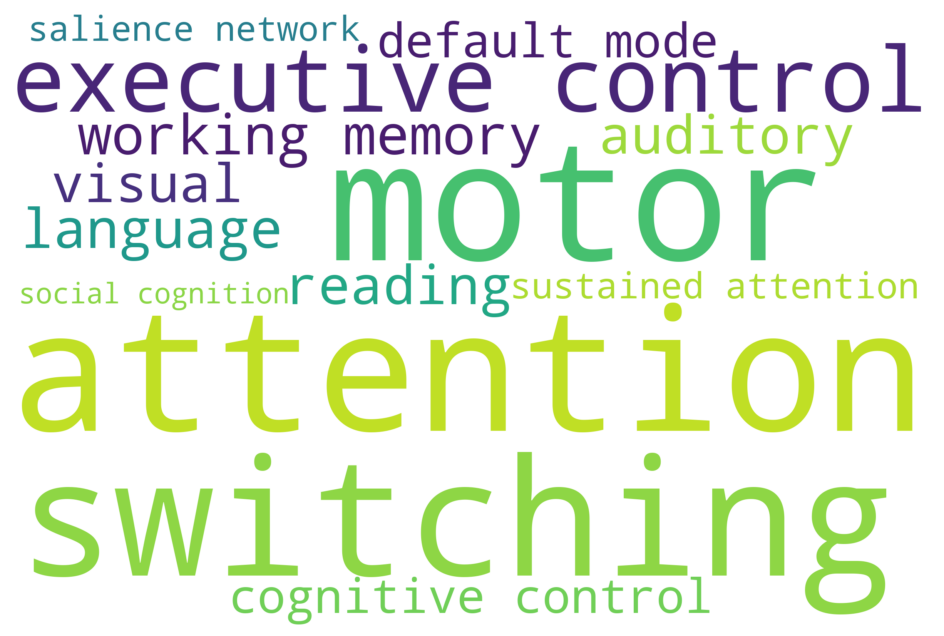

✅ 词云已生成并保存！


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np

# ================== 加载数据 ==================
df = pd.read_csv("/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth/Neurosynth_III_posneg/final_Subtype2_Negative_cognitive_p_values.csv")

# 只保留显著正相关的词（推荐做法）
df_sig = df[(df['Significant_FDR'] == True) & (df['Real_R'] > 0)]

# 创建 词:权重 字典
freq_dict = dict(zip(df_sig['Term'], df_sig['Real_R']))

# ================== 生成词云 ==================
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    colormap='viridis',           # 或者 'plasma', 'magma', 'inferno'
    prefer_horizontal=0.9,
    max_words=30,
    contour_width=1,
    contour_color='steelblue',
    scale=2,
    relative_scaling=0.5
).generate_from_frequencies(freq_dict)

# ================== 绘图 ==================
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title('Subtype 2 Negative Pattern - Associated Cognitive Terms\n'
#           '(Word size = correlation strength | Only FDR-significant positive associations)',
#           fontsize=14, pad=20)

# 保存高清图片
plt.savefig('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth/Neurosynth_III_posneg/subtype2_negative_wordcloud_python.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ 词云已生成并保存！")

将 z-map映射到大脑上，这了判断了 p值要显著且 z 值<0

In [2]:
import pandas as pd
import numpy as np
import nibabel as nib

# ==========================================
# 1. 路径设置 (请根据您的实际环境确认路径)
# ==========================================
# GLM 结果的 CSV 文件路径
csv_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth/Neurosynth_III_posneg/step1_Subtype2_vs_HC_GLM.csv'
# 您的 CIFTI 大脑模板路径
tpath = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_freesurfer/fsaverage/fsaverage_LR32k/fsaverage.BN_Atlas.32k_fs_LR.dlabel.nii'
# 输出的 dscalar 文件路径 (建议修改名称以作区分)
output_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth/Neurosynth_III_posneg/subtype2_zmap_negative.dscalar.nii'

# ==========================================
# 2. 读取并过滤 GLM 结果数据
# ==========================================
df = pd.read_csv(csv_path)

# 提取 z 值和 p 值
z_values = df['z_score'].values
p_values = df['p_value'].values

# 构建过滤后的数值向量 (基于您的要求：显著 p<0.05 且 z<0)
# 满足条件则保留 z_score，否则替换为 0
target_values = np.where((p_values < 0.05) & (z_values < 0), z_values, 0)

# ==========================================
# 3. 加载大脑模板
# ==========================================
template_img = nib.load(tpath)
render_data = template_img.get_fdata().copy()

# 原代码中的标签处理逻辑
render_data[render_data > 210] -= 210

print(f"模板顶点数: {render_data.shape[1]}")
print(f"CSV 中的脑区总数: {len(target_values)}")
print(f"👉 其中满足显著 (p<0.05) 且 Z<0 的脑区数量: {np.sum(target_values != 0)}")

# ==========================================
# 4. 将 Z 值映射到对应的标签索引上
# ==========================================
# 将模板上原来所有的非 0 值先清零，避免残留模板自带的 ID 号
render_data[:] = 0

# 重新加载一遍未清零的原始图来做 mask
orig_data = template_img.get_fdata().copy()
orig_data[orig_data > 210] -= 210

# 遍历 1 到 246 (Brainnetome 246 标准索引)
for i in range(1, len(target_values) + 1):
    mask = (orig_data == i)
    # 将过滤后的 Z 值赋给这些顶点
    render_data[mask] = target_values[i - 1]

# ==========================================
# 5. 构建并保存 CIFTI dscalar 文件
# ==========================================
# 命名此列数据的名称
scalar_axis = nib.cifti2.cifti2_axes.ScalarAxis(['Significant_Negative_Z'])
brain_model_axis = template_img.header.get_axis(1)
new_header = nib.cifti2.Cifti2Header.from_axes((scalar_axis, brain_model_axis))
new_img = nib.Cifti2Image(render_data, header=new_header)
new_img.to_filename(output_path)

print(f"✅ 映射完成！文件已保存至: {output_path}")

模板顶点数: 59412
CSV 中的脑区总数: 246
👉 其中满足显著 (p<0.05) 且 Z<0 的脑区数量: 238
✅ 映射完成！文件已保存至: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step15_Neurosynth/Neurosynth_III_posneg/subtype2_zmap_negative.dscalar.nii


震源中心-将 r 值映射到脑上方便展示，这里只映射显著的脑区

In [1]:
import nibabel as nib
import numpy as np
import pandas as pd

# ==============================================================
# 1. 路径设置 (请根据您的实际环境修改文件路径)
# ==============================================================
template_path = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_freesurfer/fsaverage/fsaverage_LR32k/fsaverage.BN_Atlas.32k_fs_LR.dlabel.nii'
Regionscsv_path = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv'

# 【修改点 1】: 将这里换成您的 BrainSMASH 结果数据路径
csv_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step16_Epicenters/subtype1_FullBrain_Epicenters_BrainSMASH2.csv'

# 输出文件路径
output_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step16_Epicenters/subtype1_Epicenter_r_sig.dscalar.nii'

# ==============================================================
# 2. 模板加载与处理
# ==============================================================
template = nib.load(template_path)
# 建议使用 .copy()，避免直接在原数据内存上修改
label = template.get_fdata().copy()
print("Template label shape:", label.shape)

# 保留您原代码的处理逻辑
label[label > 210] -= 210

# ==============================================================
# 3. 读取数据
# ==============================================================
Regions_data = pd.read_csv(Regionscsv_path)
region = Regions_data['regions'][0:210]

# 加载包含 Epicenter_r 的统计结果
epi_data = pd.read_csv(csv_path)
print("BrainSMASH Data shape:", epi_data.shape)

# 创建一个新的数组用于存储映射值 (初始全为0，不显著的区域将保持为0)
mapped_data = np.zeros_like(label)

# ==============================================================
# 4. 循环遍历脑区，判断显著性并映射
# ==============================================================
for i, regionname in enumerate(region):
    # 图谱索引对应的数值是从 1 开始的
    label_idx = i + 1

    # 【修改点 2】: 从表格中查找当前 regionname 对应的行
    row_data = epi_data[epi_data['Region'] == regionname]

    if not row_data.empty:
        # 获取 r 值和 p 值
        r_val = row_data['Epicenter_r'].values[0]
        p_val = row_data['p_surrogate'].values[0]

        # 判断显著性：如果 p < 0.05，则使用 r_val；如果不显著，则置为 0
        if p_val < 0.05:
            val_to_map = r_val
        else:
            val_to_map = 0

        print(f"脑区 {label_idx} ({regionname}): r={r_val:.4f}, p={p_val:.4f}  ---> 映射值: {val_to_map}")
    else:
        # 如果数据中没找到该脑区（容错处理），默认设为 0
        val_to_map = 0
        print(f"脑区 {label_idx} ({regionname}): 未在数据中找到  ---> 映射值: 0")

    # 将判断后的值映射到模板的对应位置
    index = np.where(label == label_idx)
    mapped_data[index] = val_to_map

# 检查映射后的数据形状
print("Mapped data shape:", mapped_data.shape)

# ==============================================================
# 5. 创建并保存 dscalar.nii 文件
# ==============================================================
# 将列名命名为您实际映射的指标名称，以便可视化软件里查看
scalar_axis = nib.cifti2.cifti2_axes.ScalarAxis(['Significant_Epicenter_r'])
brain_model_axis = template.header.get_axis(1)
scalar_header = nib.cifti2.Cifti2Header.from_axes((scalar_axis, brain_model_axis))
scalar_img = nib.Cifti2Image(mapped_data, header=scalar_header)

scalar_img.to_filename(output_path)
print(f"\n✅ 映射完成！文件已保存至: {output_path}")

Template label shape: (1, 59412)
BrainSMASH Data shape: (246, 5)
脑区 1 (A8m_L): r=0.1021, p=0.5777  ---> 映射值: 0
脑区 2 (A8m_R): r=0.1228, p=0.5028  ---> 映射值: 0
脑区 3 (A8dl_L): r=0.1201, p=0.4535  ---> 映射值: 0
脑区 4 (A8dl_R): r=0.1428, p=0.4481  ---> 映射值: 0
脑区 5 (A9l_L): r=0.2246, p=0.1308  ---> 映射值: 0
脑区 6 (A9l_R): r=0.1839, p=0.2918  ---> 映射值: 0
脑区 7 (A6dl_L): r=0.1359, p=0.5071  ---> 映射值: 0
脑区 8 (A6dl_R): r=0.2260, p=0.2317  ---> 映射值: 0
脑区 9 (A6m_L): r=0.1212, p=0.5304  ---> 映射值: 0
脑区 10 (A6m_R): r=0.1416, p=0.4685  ---> 映射值: 0
脑区 11 (A9m_L): r=0.2155, p=0.2354  ---> 映射值: 0
脑区 12 (A9m_R): r=0.1655, p=0.3393  ---> 映射值: 0
脑区 13 (A10m_L): r=0.2785, p=0.0756  ---> 映射值: 0
脑区 14 (A10m_R): r=0.2832, p=0.0848  ---> 映射值: 0
脑区 15 (46d_L): r=0.1849, p=0.2853  ---> 映射值: 0
脑区 16 (46d_R): r=0.1588, p=0.3690  ---> 映射值: 0
脑区 17 (IFJ_L): r=0.2490, p=0.1304  ---> 映射值: 0
脑区 18 (IFJ_R): r=0.1511, p=0.4308  ---> 映射值: 0
脑区 19 (A46_L): r=0.2514, p=0.1216  ---> 映射值: 0
脑区 20 (A46_R): r=0.1806, p=0.1760  ---> 映射值: 

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn.conftest import matplotlib

'''
    计算两组亚型的 8 个网络水平的 variance，
    然后进行差异比较 (ANCOVA：控制 age, sex, mean_fd)，
    同时包含 3-Sigma 异常值剔除后的对比。
'''
matplotlib.use('Agg')

# ==========================================
# 1. 加载网络数据
# ==========================================
base_dir = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_verify/Step4_Variance_Diff/'
df1 = pd.read_csv(base_dir + 'subtype1_DZ_INT_8net.csv')
df2 = pd.read_csv(base_dir + 'HC_DZ_INT_8net.csv')

# 提取用于计算方差的网络列（确保只包含这8个网络）
network_cols = ['Subcortical', 'Visual', 'Somatomotor', 'Dorsal_Attention',
                'Ventral_Attention', 'Limbic', 'Frontoparietal', 'Default']

# ==========================================
# 2. 计算每个被试在 8 个网络上的方差，并合并数据
# ==========================================
df1['variance'] = df1[network_cols].var(axis=1)
df2['variance'] = df2[network_cols].var(axis=1)

df1['group'] = 'Subtype 1'
df2['group'] = 'Subtype 2'

# 提取后续统计分析需要的列
keep_cols = ['subID', 'group', 'age', 'sex', 'mean_fd', 'variance']
df_raw = pd.concat([df1[keep_cols], df2[keep_cols]], ignore_index=True).dropna()

# ==========================================
# 3. 识别离群点 (3-Sigma 准则) - 组内分别计算 Z-score
# ==========================================
# 按组别分别计算 variance 的 z-score
df_raw['variance_zscore'] = df_raw.groupby('group')['variance'].transform(lambda x: zscore(x, ddof=1))
# 过滤掉绝对值 > 3 的离群点
df_clean = df_raw[np.abs(df_raw['variance_zscore']) <= 3.0].copy()

print(f"原始数据样本量: {len(df_raw)}")
print(f"剔除 3-Sigma 离群点后的样本量: {len(df_clean)} (剔除了 {len(df_raw) - len(df_clean)} 个)")

# ==========================================
# 4. 统计检验：ANCOVA 控制协变量
# ==========================================
def run_ancova(data):
    """
    运行协方差分析，返回 ANOVA 表，以及组别差异的 F 值和 P 值
    """
    model = ols('variance ~ C(group) + age + C(sex) + mean_fd', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_val = anova_table.loc['C(group)', 'PR(>F)']
    f_val = anova_table.loc['C(group)', 'F']
    return anova_table, f_val, p_val

anova_raw, f_raw, p_raw = run_ancova(df_raw)
anova_clean, f_clean, p_clean = run_ancova(df_clean)

print("\n========== ANCOVA 结果 (Original Data) ==========")
print(anova_raw)
print("\n========== ANCOVA 结果 (Cleaned Data) ==========")
print(anova_clean)

# ==========================================
# 5. 绘图对比
# ==========================================
plt.figure(figsize=(14, 6))

# --- 左图：原始数据分布 ---
plt.subplot(1, 2, 1)
sns.boxplot(x='group', y='variance', data=df_raw, palette='Set2', showfliers=True)
sns.stripplot(x='group', y='variance', data=df_raw, color='black', alpha=0.3, jitter=True)
# 将 ANCOVA 得到的真实 P 值打印在标题上
plt.title(f'Original Network Variance\nANCOVA (covFD, age, sex) p={p_raw:.4e}', fontsize=13)
plt.ylabel('Variance')
plt.xlabel('Subtype')

# --- 右图：剔除离群点后的分布 ---
plt.subplot(1, 2, 2)
sns.boxplot(x='group', y='variance', data=df_clean, palette='Pastel2', showfliers=False)
sns.stripplot(x='group', y='variance', data=df_clean, color='black', alpha=0.3, jitter=True)
plt.title(f'Cleaned Network Variance (>3SD Removed)\nANCOVA (covFD, age, sex) p={p_clean:.4e}', fontsize=13)
plt.ylabel('Variance')
plt.xlabel('Subtype')

plt.tight_layout()
save_path_img = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_verify/Step4_Variance_Diff/network_variance_covFD_comparison.png'
plt.savefig(save_path_img, dpi=300)
plt.show()
print(f"\n绘图已保存至: {save_path_img}")

# 保存带有方差计算结果的文件
save_path_csv = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_verify/Step4_Variance_Diff//subtype1_subtype2_network_variances_covFD.csv'
df_raw.drop(columns=['variance_zscore']).to_csv(save_path_csv, index=False)
print(f"数据表已保存至: {save_path_csv}")

原始数据样本量: 92
剔除 3-Sigma 离群点后的样本量: 90 (剔除了 2 个)

========== ANCOVA 结果 (Original Data) ==========
            sum_sq    df          F    PR(>F)
C(group)  0.038819   1.0   7.987173  0.005843
C(sex)    0.063394   1.0  13.043653  0.000508
age       0.018453   1.0   3.796716  0.054576
mean_fd   0.036044   1.0   7.416283  0.007810
Residual  0.422834  87.0        NaN       NaN

========== ANCOVA 结果 (Cleaned Data) ==========
            sum_sq    df          F    PR(>F)
C(group)  0.034624   1.0  11.032542  0.001321
C(sex)    0.033341   1.0  10.623626  0.001607
age       0.011638   1.0   3.708411  0.057482
mean_fd   0.018516   1.0   5.900013  0.017248
Residual  0.266759  85.0        NaN       NaN


/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_19814/239546544.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='variance', data=df_raw, palette='Set2', showfliers=True)
/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_19814/239546544.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='variance', data=df_clean, palette='Pastel2', showfliers=False)



绘图已保存至: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_verify/Step4_Variance_Diff/network_variance_covFD_comparison.png
数据表已保存至: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_verify/Step4_Variance_Diff//subtype1_subtype2_network_variances_covFD.csv


/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_19814/239546544.py:98: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
